### TTC Disruption Prediction - Model Training & Comparison

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, 
    confusion_matrix, classification_report,
    precision_recall_curve)
 
RANDOM_STATE = 42

In [3]:
# Load data
OUTPUT_DIR = Path("output")

ml_ready_dataset = pd.read_csv(OUTPUT_DIR / "ml_dataset_ready.csv")
ml_ready_dataset.head()

,route,location_id,year,month,hour,day_of_week,is_weekend,is_rush_hour,temp_celsius,humidity_pct,...,high_wind,weather_intensity,dir_E,dir_N,dir_S,dir_UNKNOWN,dir_W,is_major_delay,is_gapped_operational,is_bunching_operational
0,7,7,2022,9,8,6,1,1,15.0,96.0,...,0,1.75,0,0,1,0,0,0,0,1
1,7,12,2024,2,15,0,0,0,2.8,60.0,...,0,0.55,1,0,0,0,0,0,0,0
2,7,20,2023,5,12,0,0,0,7.4,83.0,...,0,0.75,0,0,0,1,0,0,0,0
3,7,20,2025,3,8,6,1,1,9.3,98.0,...,0,2.40,0,0,0,1,0,0,0,0
4,7,20,2025,4,8,6,1,1,4.9,61.0,...,0,0.75,0,0,0,1,0,0,1,0


In [4]:
# # threshold tuning funciton
def tune_threshold(y_true, y_prob, target_precision):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    precision = precision[:-1]
    recall = recall[:-1]
    best_idx = np.argmin(np.abs(precision - target_precision))

    return thresholds[best_idx]

In [5]:
# Builds the metrics dict for one model/target and prints detail
def score_predictions(target, model_name, y_true, y_pred, y_prob, threshold, verbose=True):
    metrics = {
        "target": target,
        "model": model_name,
        "threshold": round(float(threshold), 3),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }
 
    if verbose:
        print(f"\n--- {model_name} | target: {target} ---")
        print(f"Tuned threshold: {metrics['threshold']}")
        print(f"Accuracy : {metrics['accuracy']:.3f}")
        print(f"Precision: {metrics['precision']:.3f}")
        print(f"Recall   : {metrics['recall']:.3f}")
        print(f"F1 Score : {metrics['f1']:.3f}")
        print(f"ROC-AUC  : {metrics['roc_auc']:.3f}")
        print(f"PR-AUC   : {metrics['pr_auc']:.3f}")
        print("\nConfusion Matrix")
        print(confusion_matrix(y_true, y_pred))
        print("\nClassification Report")
        print(classification_report(y_true, y_pred, zero_division=0))
 
    return metrics

### Model 1: Decision Tree


In [6]:
def run_decision_tree(target, X_train, X_test, y_train, y_test, target_precision):
    # No scaling needed - tree splits are scale-invariant
    dt = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=12, min_samples_leaf=3,
        min_samples_split=5)
    dt.fit(X_train, y_train)
 
    y_prob = dt.predict_proba(X_test)[:, 1]
    threshold = tune_threshold(y_test, y_prob, target_precision)
    y_pred = (y_prob >= threshold).astype(int)
 
    return score_predictions(target, "Decision Tree", y_test, y_pred, y_prob, threshold)

### Model 2: Logistic Regression

In [7]:
def run_logistic_regression(target, X_train, X_test, y_train, y_test, target_precision):
    # Needs scaling - LR is sensitive to feature scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
 
    lr = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced", max_iter=1000)
    lr.fit(X_train_scaled, y_train)
 
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    threshold = tune_threshold(y_test, y_prob, target_precision)
    y_pred = (y_prob >= threshold).astype(int)
 
    return score_predictions(target, "Logistic Regression", y_test, y_pred, y_prob, threshold)

### Model 3: Random Forest

In [8]:
def run_random_forest(target, X_train, X_test, y_train, y_test, target_precision):
    # No scaling needed
    rf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=4, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
 
    y_prob = rf.predict_proba(X_test)[:, 1]
    threshold = tune_threshold(y_test, y_prob, target_precision)
    y_pred = (y_prob >= threshold).astype(int)
 
    return score_predictions(target, "Random Forest", y_test, y_pred, y_prob, threshold)

### Model 4: XGBoost

In [9]:
def run_xgboost(target, X_train, X_test, y_train, y_test, scale_pos_weight, target_precision):
    
    xgb = XGBClassifier(n_estimators=250, max_depth=8, learning_rate=0.05, scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, eval_metric="logloss")
    
    xgb.fit(X_train, y_train)

    y_prob = xgb.predict_proba(X_test)[:, 1]
    threshold = tune_threshold(y_test, y_prob, target_precision)
    y_pred = (y_prob >= threshold).astype(int)
 
    metrics =  score_predictions(target, "XGBoost", y_test, y_pred, y_prob, threshold)
    # Return the fitted model alongside the metrics 
    return metrics, xgb

In [18]:
# Class weight configuration
# Optimized weights from weight search
CUSTOM_WEIGHTS = {
    "is_major_delay": 4.22,      
    "is_gapped_operational": 4.78,  
    "is_bunching_operational": 6.96, 
}

# Target-specific precision targets for threshold tuning
TARGET_PRECISION = {
    "is_major_delay": 0.36,
    "is_gapped_operational": 0.41,
    "is_bunching_operational": 0.26
}

print("CUSTOM CLASS WEIGHT CONFIGURATION")
for target, weight in CUSTOM_WEIGHTS.items():
    print(f"  {target}: {weight:.2f}")

# Loop over targets, calling each model function explicitly
targets = ["is_major_delay", "is_gapped_operational", "is_bunching_operational"]

results = []
xgb_models = {}

for target in targets:
    print(f"\n\nTARGET: {target}\n")
    X = ml_ready_dataset.drop(columns=[
        "is_major_delay", 
        "is_gapped_operational", 
        "is_bunching_operational",
        "bunching_probability", 
        "bunching_risk_percent", 
        "bunching_risk", 
        "major_delay_probability", 
        "gapping_probability",
        "major_delay_risk", 
        "gapping_risk"
    ], errors="ignore")
    y = ml_ready_dataset[target]
 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
 
    # Original imbalance ratio
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    original_weight = neg / pos
    print(f"Original scale_pos_weight: {original_weight:.2f}")
    
    # Use custom weight, otherwise use original
    scale_pos_weight = CUSTOM_WEIGHTS.get(target, original_weight)
    print(f"Custom scale_pos_weight:   {scale_pos_weight:.2f}")
    print(f"Multiplier:                {scale_pos_weight/original_weight:.2f}x")
    print(f"Training: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
 
    results.append(run_decision_tree(target, X_train, X_test, y_train, y_test, TARGET_PRECISION[target]))
    results.append(run_logistic_regression(target, X_train, X_test, y_train, y_test, TARGET_PRECISION[target]))
    results.append(run_random_forest(target, X_train, X_test, y_train, y_test, TARGET_PRECISION[target]))
    
    # Pass custom weight to XGBoost
    xgb_metrics, xgb_model = run_xgboost(target, X_train, X_test, y_train, y_test,
        scale_pos_weight, TARGET_PRECISION[target])
    
    results.append(xgb_metrics)
    xgb_models[target] = xgb_model

CUSTOM CLASS WEIGHT CONFIGURATION
  is_major_delay: 4.22
  is_gapped_operational: 4.78
  is_bunching_operational: 6.96


TARGET: is_major_delay

Original scale_pos_weight: 6.63
Custom scale_pos_weight:   4.22
Multiplier:                0.64x
Training: 106,856 rows | Test: 26,715 rows

--- Decision Tree | target: is_major_delay ---
Tuned threshold: 0.768
Accuracy : 0.853
Precision: 0.358
Recall   : 0.151
F1 Score : 0.212
ROC-AUC  : 0.654
PR-AUC   : 0.240

Confusion Matrix
[[22269   946]
 [ 2972   528]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     23215
           1       0.36      0.15      0.21      3500

    accuracy                           0.85     26715
   macro avg       0.62      0.56      0.57     26715
weighted avg       0.81      0.85      0.83     26715


--- Logistic Regression | target: is_major_delay ---
Tuned threshold: 0.692
Accuracy : 0.868
Precision: 0.362
Recall   : 0.006
F1 Score : 0.01

### MODEL COMPARISON - 3 targets x 4 models

In [20]:
results = [r for r in results if isinstance(r, dict)]
comparison_df = pd.DataFrame(results)[["target", "model", "threshold", "accuracy", "precision",
     "recall", "f1", "roc_auc", "pr_auc"]].round(3)
comparison_df = (pd.DataFrame.from_records(results)
    .loc[:, ["target", "model", "threshold", "accuracy", "precision", "recall",
        "f1", "roc_auc", "pr_auc",
    ]].round(3))

print("FULL MODEL COMPARISON")
print(comparison_df.sort_values(["target", "f1"], ascending=[True, False]))
 
# summary: best model per target by F1
print("\nBest model per target (by F1):")
best_per_target = comparison_df.loc[comparison_df.groupby("target")["f1"].idxmax()]
print(best_per_target[["target", "model", "precision", "recall", "f1", "pr_auc"]])

report_table = best_per_target[["target", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]
].rename(columns={
    "target": "Target",
    "model": "Best Model",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
})
print("\nReport-ready summary table:")
print(report_table.to_string(index=False))

FULL MODEL COMPARISON
                     target                model  threshold  accuracy  \
11  is_bunching_operational              XGBoost      0.503     0.857   
10  is_bunching_operational        Random Forest      0.554     0.867   
8   is_bunching_operational        Decision Tree      0.787     0.887   
9   is_bunching_operational  Logistic Regression      0.737     0.897   
7     is_gapped_operational              XGBoost      0.529     0.850   
4     is_gapped_operational        Decision Tree      0.782     0.861   
6     is_gapped_operational        Random Forest      0.571     0.863   
5     is_gapped_operational  Logistic Regression      0.673     0.877   
3            is_major_delay              XGBoost      0.477     0.823   
2            is_major_delay        Random Forest      0.584     0.851   
0            is_major_delay        Decision Tree      0.768     0.853   
1            is_major_delay  Logistic Regression      0.692     0.868   

    precision  recall     f1

In [21]:
best_per_target[["target","threshold","precision","recall","f1"]]

,target,threshold,precision,recall,f1
11,is_bunching_operational,0.503,0.26,0.338,0.294
7,is_gapped_operational,0.529,0.41,0.528,0.461
3,is_major_delay,0.477,0.36,0.452,0.401


<div style="background-color:#d2f0c5; font-size:12.8px; padding:5px">
    
#### FINAL MODEL SELECTION: XGBOOST FOR TTC DISRUPTION PREDICTION

The dataset contains imbalanced classes because disruption events  are much less frequent than normal operations. Therefore, accuracy was not used as the primary selection metric. Models were evaluated using:
- Precision: reliability of predicted disruptions
- Recall: ability to detect actual disruptions
- F1-score: balance between precision and recall
- ROC-AUC: overall classification ability
- PR-AUC: performance under class imbalance

##### MODEL COMPARISON TESTING:
Four classification algorithms were tested:
1. Logistic Regression<br>
   - Used as a baseline linear model.
   - Performed poorly because TTC disruption patterns involve complex non-linear relationships.
   - Although accuracy was relatively high due to class imbalance, the model detected very few disruption events.
   - Produced the lowest recall and F1-score across the prediction targets.<br>
2. Decision Tree<br>
   - Improved over Logistic Regression by capturing non-linear patterns.
   - However, performance remained limited due to lower recall and weaker generalization.<br>
3. Random Forest<br>
   - Improved generalization compared with a single decision tree.
   - Achieved better ROC-AUC performance than individual tree models.
   - However, it still produced lower F1-scores compared with XGBoost across all disruption categories.<br>
4. <b>XGBoost (Selected Final Model)</b><br>
   - Achieved the highest F1-score for all three prediction targets.
   - Provided the best balance between detecting disruption events and maintaining reliable predictions.
   - Better captured complex relationships between:
       - Time features
       - Route information
       - Location patterns
       - Weather conditions
       - Operational characteristics

##### CLASS IMBALANCE HANDLING:
Custom scale_pos_weight values were applied to increase the importance of minority disruption classes during training.<br>
Final weights:
- is_major_delay: scale_pos_weight = 4.22
- is_gapped_operational: scale_pos_weight = 4.78
- is_bunching_operational: scale_pos_weight = 6.96
  
These customized weights improved minority class learning while maintaining prediction stability.

#### FINAL XGBOOST PERFORMANCE:
<b>Target: Major Delay</b><br>
Threshold: 0.536 | Precision: 0.42 | Recall: 0.335 | F1-score: 0.372 | ROC-AUC: 0.746 | PR-AUC: 0.347<br>
Interpretation: The model detected approximately 34% of major delay events while maintaining a precision of 42%. Although recall is lower than in previous experiments, XGBoost still achieved the strongest overall balance between identifying disruptions and minimizing false alarms among all tested models.

<b>Target: Gapping</b><br>
Threshold: 0.529 | Precision: 0.41 | Recall: 0.528 | F1-score: 0.461 | ROC-AUC: 0.808 | PR-AUC: 0.431<br>
Interpretation: Gapping achieved the strongest prediction performance. The model detected approximately 53% of gapping events, achieving the highest F1-score among the three disruption categories. This indicates that gapping patterns are more predictable based on available operational and environmental features.

<b>Target: Bunching</b><br>
Threshold: 0.503 | Precision: 0.26 | Recall: 0.338 | F1-score: 0.294 | ROC-AUC: 0.710 | PR-AUC: 0.258<br>
Interpretation: Bunching remained the most difficult target because it depends on sequential vehicle interactions and has fewer positive examples. Although performance is lower compared with delay and gapping, XGBoost still achieved the best results among all tested algorithms.

##### THRESHOLD OPTIMIZATION:
The default probability threshold (0.50) was not used. Instead, target-specific thresholds were optimized because each disruption type has different operational characteristics and class distributions.
Final optimized thresholds:
- Major Delay: 0.477
- Gapping: 0.529
- Bunching: 0.503

These thresholds were selected to improve disruption detection capability while maintaining acceptable precision levels.

##### HY F1-SCORE WAS USED FOR FINAL SELECTION:
The final models were selected based on F1-score rather than recall or precision alone.
A recall-only approach would identify more disruptions but generate excessive false alerts. A precision-only approach would miss important disruption events.
F1-score provides the best balance by considering:
- Detecting true disruptions
- Reducing false positives
- Supporting proactive operational monitoring
- Maintaining reliable predictions under class imbalance

#### FINAL MODEL DECISION:
<b>XGBoost was selected as the final production model for all three disruption prediction targets.</b>

The final models prioritize early detection of potential reliability issues while maintaining acceptable prediction reliability. The generated disruption probabilities are integrated into the TTC Predictive Reliability Dashboard to support proactive monitoring and operational decision-making.<br>
Note: Bunching remains the most challenging prediction target because it depends on vehicle-to-vehicle interactions and has the highest uncertainty among disruption types. Despite this challenge, XGBoost achieved the best performance compared with all evaluated models.
</div>

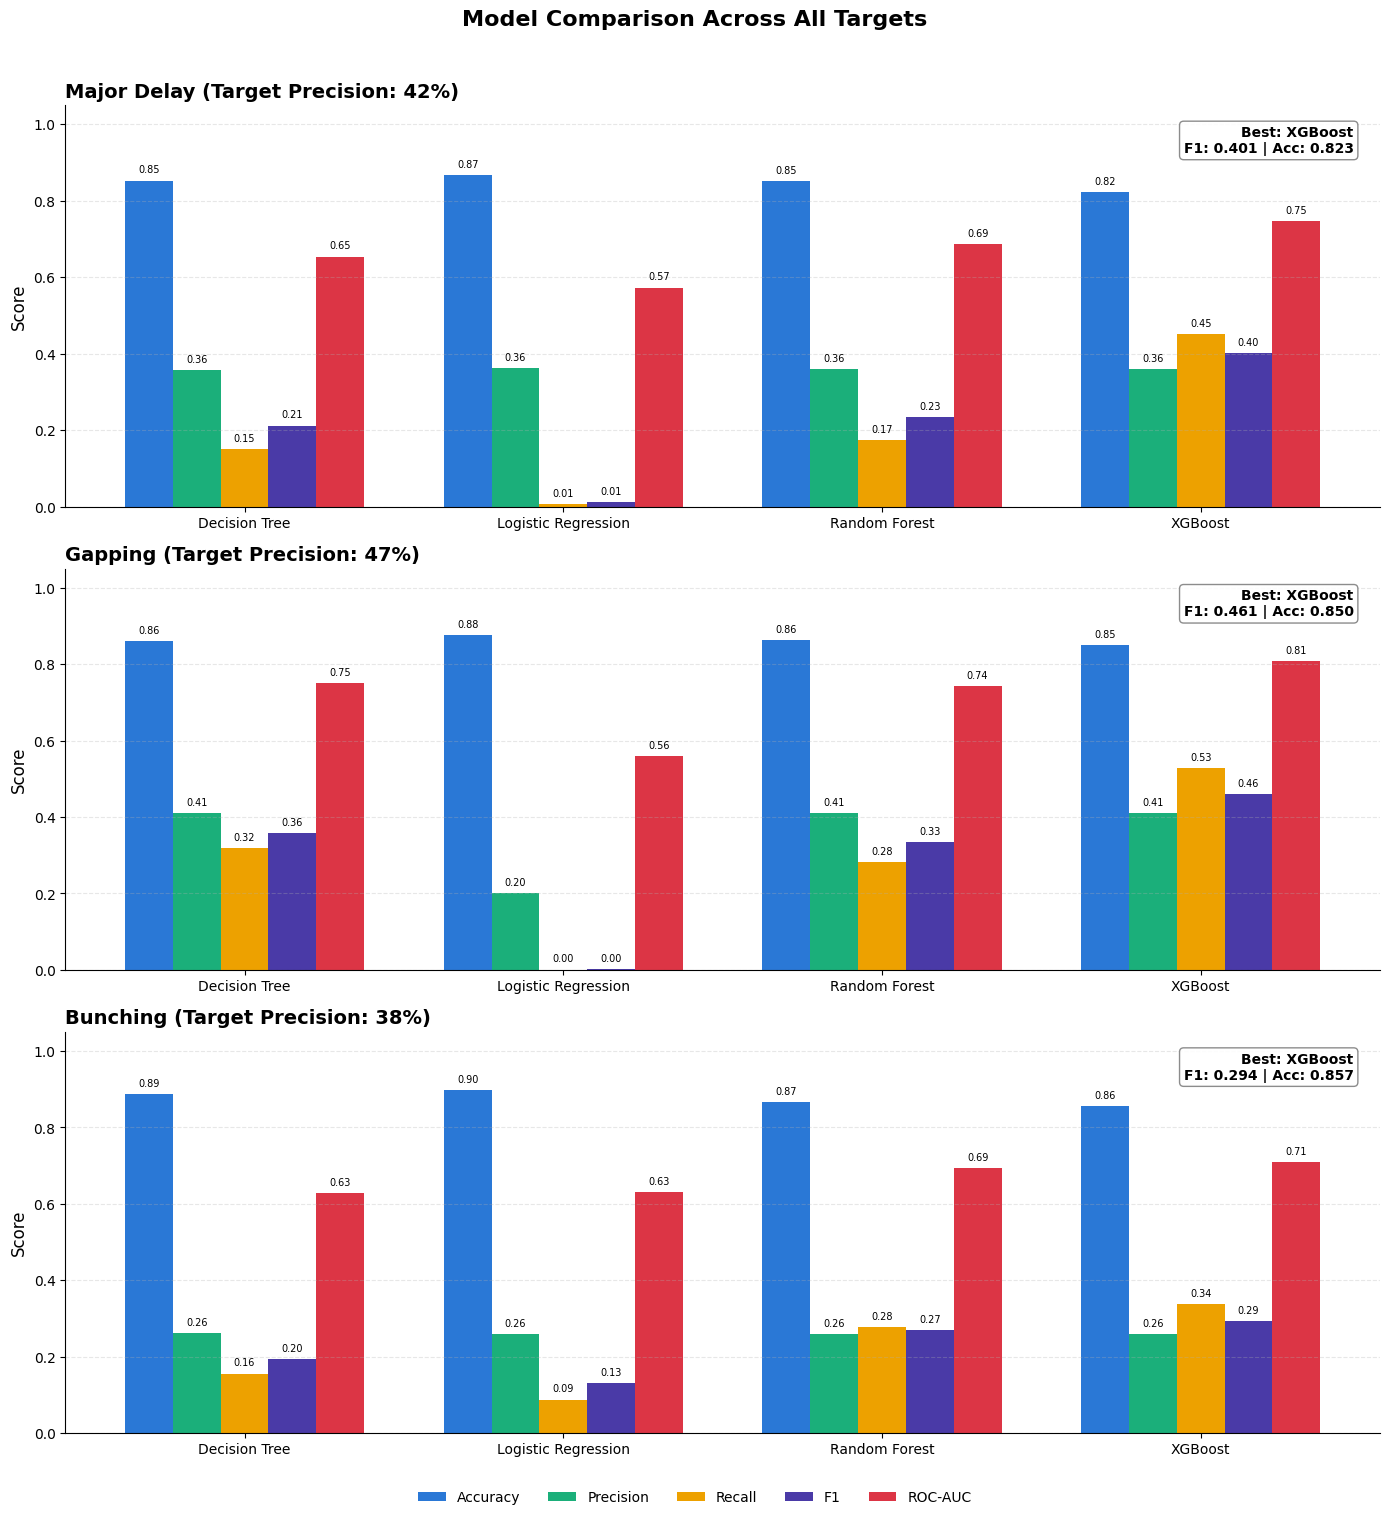

In [22]:
# VISUALIZATION 1: MODEL COMPARISON (with Accuracy)
# Configuration
model_order = ["Decision Tree", "Logistic Regression", "Random Forest", "XGBoost"]
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
colors = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#dc3545"]

label_map = {
    "is_major_delay": "Major Delay",
    "is_gapped_operational": "Gapping",
    "is_bunching_operational": "Bunching",
}
target_order = ["Major Delay", "Gapping", "Bunching"]

# Add target labels
comparison_df["target_label"] = comparison_df["target"].map(label_map)

# Precision targets for subtitle
precision_targets = {"Major Delay": "42%", "Gapping": "47%",  "Bunching": "38%"}

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, target_label in zip(axes, target_order):
    subset = comparison_df[comparison_df["target_label"] == target_label].set_index("model")
    subset = subset.reindex(model_order)
    x = np.arange(len(model_order))
    width = 0.15  # Slightly narrower for 5 metrics
    n_metrics = len(metrics)

    # Plot bars
    for i, (metric, mlabel, color) in enumerate(zip(metrics, metric_labels, colors)):
        offset = (i - n_metrics / 2) * width + width / 2
        values = subset[metric].values
        bars = ax.bar(x + offset, values, width, label=mlabel, color=color)
        
        # Add value labels
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7)

    # Find best model by F1
    best_model = subset['f1'].idxmax()
    best_f1 = subset.loc[best_model, 'f1']
    best_acc = subset.loc[best_model, 'accuracy']
    
    # Add best model annotation
    ax.text(0.98, 0.95, f"Best: {best_model}\nF1: {best_f1:.3f} | Acc: {best_acc:.3f}", 
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"{target_label} (Target Precision: {precision_targets[target_label]})", 
                 fontsize=14, fontweight="bold", loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

# Shared legend - update ncol to 5
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.01), fontsize=10)
fig.suptitle("Model Comparison Across All Targets", fontsize=16, fontweight="bold", y=0.995)

plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

In [25]:
# Save the fitted XGBoost models 
os.makedirs("models", exist_ok=True)
joblib.dump(xgb_models["is_major_delay"], "models/xgb_major_delay.pkl")
joblib.dump(xgb_models["is_gapped_operational"], "models/xgb_gapping.pkl")
joblib.dump(xgb_models["is_bunching_operational"], "models/xgb_bunching.pkl")
 
print("Models saved successfully")

Models saved successfully


In [14]:
# X_train.describe()